# 07 — Sensitivity analysis

Created with Grok Build

Which components dominate accuracy?

1. **OAT (one-at-a-time)** over each tolerance / limit interval → tornado chart  
2. **Normalized sensitivity** $S_x^m=(x/m)\,\partial m/\partial x$  
3. **$|H(f)|$ sensitivity vs frequency**


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
# Operating point overrides
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}


,parameter,metric,nominal_metric,metric_at_lo,metric_at_hi,span,max_abs_delta
0,R1,fc_hz,19766.713183,19776.265393,19757.175243,-1.909015e+01,9.552210e+00
1,R1,passband_gain,0.999993,0.999993,0.999993,-2.698542e-08,1.349987e-08
2,R1,gain_at_fdesign,0.700653,0.700919,0.700386,-5.326592e-04,2.663462e-04
3,R1,phase_at_fdesign_deg,-100.861860,-100.833680,-100.890018,-5.633773e-02,2.817957e-02
4,R2,fc_hz,19766.713183,19764.302743,19769.118397,4.815654e+00,2.410440e+00
5,R2,passband_gain,0.999993,0.999993,0.999993,1.805357e-08,9.026953e-09
6,R2,gain_at_fdesign,0.700653,0.700588,0.700717,1.284307e-04,6.427118e-05
7,R2,phase_at_fdesign_deg,-100.861860,-100.837817,-100.885907,-4.808906e-02,2.404673e-02
8,R3,fc_hz,19766.713183,19779.710203,19753.749999,-2.596020e+01,1.299702e+01
9,R3,passband_gain,0.999993,0.999993,0.999993,-1.873199e-08,9.375807e-09


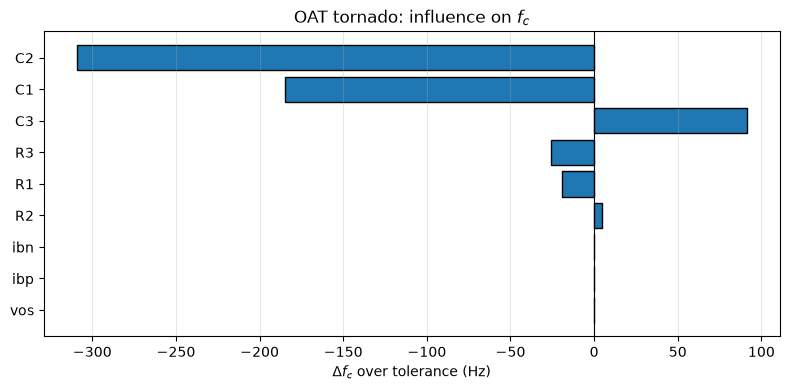

Top drivers for fc:


,parameter,metric,nominal_metric,metric_at_lo,metric_at_hi,span,max_abs_delta,abs_span
16,C2,fc_hz,19766.713183,19923.660803,19614.644160,-309.016643,156.947620,309.016643
12,C1,fc_hz,19766.713183,19859.618411,19675.081141,-184.537271,92.905228,184.537271
20,C3,fc_hz,19766.713183,19720.947464,19812.051369,91.103905,45.765719,91.103905
8,R3,fc_hz,19766.713183,19779.710203,19753.749999,-25.960204,12.997021,25.960204
0,R1,fc_hz,19766.713183,19776.265393,19757.175243,-19.090150,9.552210,19.090150


In [2]:
from opamp_design.sensitivity import full_sensitivity, sensitivity_vs_frequency

sens = full_sensitivity(p, include_opamp=True)
display(sens.oat.head(12))

# Tornado for fc_hz
sub = sens.oat[sens.oat.metric == "fc_hz"].copy()
sub["abs_span"] = sub["span"].abs()
sub = sub.sort_values("abs_span")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sub.parameter, sub.span, color="C0", edgecolor="k")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(r"$\Delta f_c$ over tolerance (Hz)")
ax.set_title(r"OAT tornado: influence on $f_c$")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "07_tornado_fc.png", dpi=150)
plt.show()

print("Top drivers for fc:")
display(sens.top_drivers("fc_hz", 5))

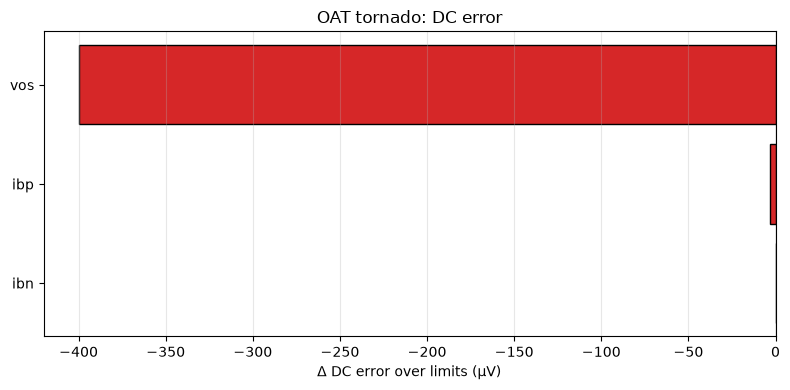

In [3]:
# DC error tornado (op-amp non-ideals dominate)
sub = sens.oat[sens.oat.metric == "dc_error"].copy()
sub["abs_span"] = sub["span"].abs()
sub = sub.sort_values("abs_span")
if len(sub):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(sub.parameter, sub.span * 1e6, color="C3", edgecolor="k")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel(r"$\Delta$ DC error over limits (µV)")
    ax.set_title("OAT tornado: DC error")
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG / "07_tornado_dc_error.png", dpi=150)
    plt.show()

metric,fc_hz,gain_at_fdesign,passband_gain,phase_at_fdesign_deg
parameter,,,,
C1,-0.466765,-0.366981,-0.000014,0.262846
C2,-0.781433,-0.618405,-0.000013,0.446868
C3,0.230461,0.176430,0.000013,0.230658
R1,-0.482886,-0.380117,-0.000013,0.279282
R2,0.121812,0.091651,0.000009,0.238391
R3,-0.656663,-0.520490,-0.000009,0.422700


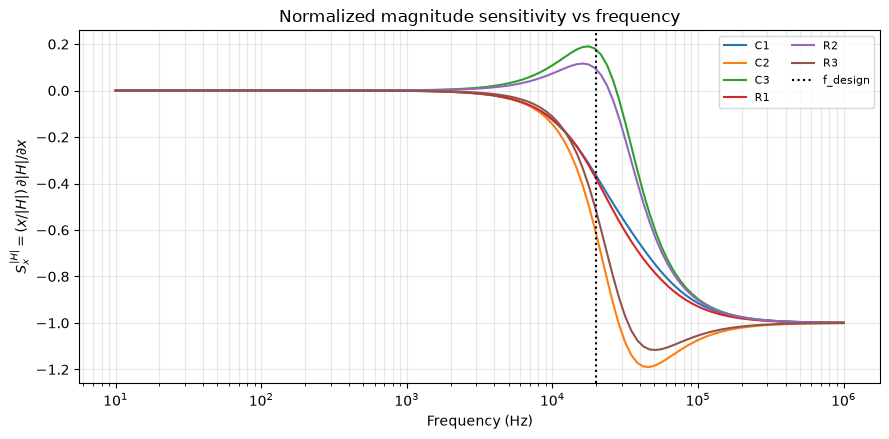

In [4]:
# Normalized sensitivity table for passives
norm = sens.normalized
piv = norm.pivot(index="parameter", columns="metric", values="normalized_sensitivity")
display(piv)

# |H| sensitivity vs frequency
sf = sensitivity_vs_frequency(p)
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, g in sf.groupby("parameter"):
    ax.semilogx(g.f_hz, g.S_mag, label=name)
ax.axvline(p.op.f_design_hz, color="k", ls=":", label="f_design")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"$S_x^{|H|}=(x/|H|)\,\partial|H|/\partial x$")
ax.set_title(r"Normalized magnitude sensitivity vs frequency")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "07_sensitivity_vs_freq.png", dpi=150)
plt.show()

### Reading the results

- Near DC, $|H|\approx 1$ is almost insensitive to $R,C$ (unity-gain topology).  
- Near $f_c$ and above, $C_1,R_1$ and the Sallen–Key set ($R_2,R_3,C_2,C_3$) dominate.  
- **DC accuracy** is dominated by $V_{OS}$; $I_B\cdot(R_1+R_2+R_3)$ is µV-class at 25 °C for this CMOS amp.